In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

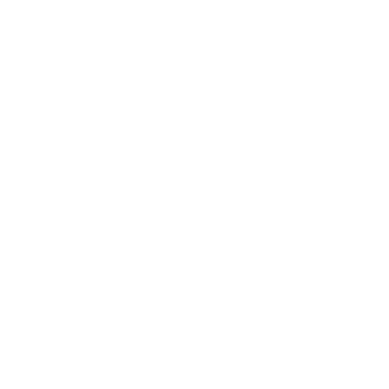

In [2]:
r,g,b = 255,255,255

plt.imshow([[(r/255, g/255, b/255)]])
plt.axis("off")
plt.show()

In [6]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    cache=False
)

In [7]:
X = mnist.data
y = mnist.target

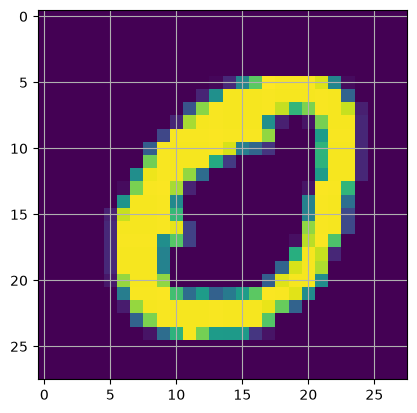

In [8]:
plt.imshow(X[8969].reshape(28, 28))
plt.grid()
#plt.axis("off")
plt.show()

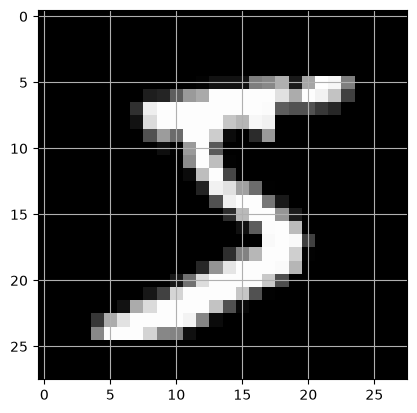

In [9]:
plt.imshow(X[0].reshape(28, 28), cmap="gray")
plt.grid()
#plt.axis("off")
plt.show()

In [10]:
X[0].reshape(28,28)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [11]:
y[0]

'5'

Split the data to training and testing data.

In [12]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

Shuffiling the dataset to eliminate any rows which are similar. example: many serial rows of '1's 


In [13]:
shuffle_index=np.random.permutation(60000)
X_train=X_train[shuffle_index]
y_train=y_train[shuffle_index]

First trying a Binary classifier considering 1 and not 1.

(In book they considered 5. But when i tried on 5 the performance was too low becasue of many factors as less data to train and all.
1 has more number of data and is bit easy to identify compared to other numbers . Hence I am considering 1).

In [14]:
y_train.shape

(60000,)

In [15]:
y_train_1=(y_train=='1') #True for all 5's and fasle for all not 5's
y_test_1=(y_test=='1')

In [16]:
from sklearn.linear_model import SGDClassifier
model = SGDClassifier(random_state=42)
model.fit(X_train, y_train_1)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

In [17]:
y_pred_1=model.predict(X_test)

In [18]:
print(model.score(X_train,y_train_1))
print(model.score(X_test,y_test_1))

0.9929166666666667
0.9923


In [19]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("Accuracy Score:",accuracy_score(y_test_1,y_pred_1))
print("Confusion Matrix:\n",confusion_matrix(y_test_1,y_pred_1))
print("Classification Report:\n",classification_report(y_test_1,y_pred_1))

Accuracy Score: 0.9923
Confusion Matrix:
 [[8833   32]
 [  45 1090]]
Classification Report:
               precision    recall  f1-score   support

       False       0.99      1.00      1.00      8865
        True       0.97      0.96      0.97      1135

    accuracy                           0.99     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.99      0.99      0.99     10000



**Identifying False Trues and True Falses and True Trues**

In [20]:
index=0
ft,tf,tt=[],[],[]
for actual,pred in zip(y_test_1,y_pred_1):
    if actual==False and pred==True:
        ft.append(index)
    elif actual==True and pred==False:
        tf.append(index)
    elif actual and pred:
        tt.append(index)
    index+=1
print("These numbers are identified as 1 :",np.unique(y_test[ft]))
print("Total False numbers classified as True:",len(ft))
print("Total True numbers classified as False:",len(tf))
print("Total True numbers classified as True:",len(tt))

These numbers are identified as 1 : ['2' '4' '5' '6' '7' '8' '9']
Total False numbers classified as True: 32
Total True numbers classified as False: 45
Total True numbers classified as True: 1090


**Identifying the number of False 1's identified as True 1's.**

These False numbers are predicted as 1


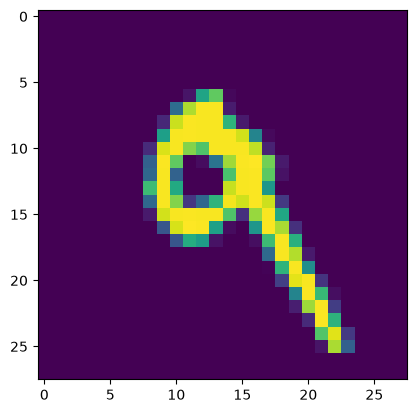

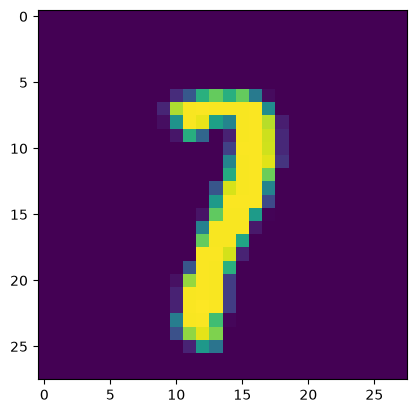

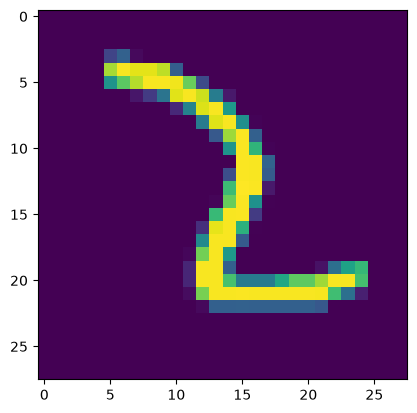

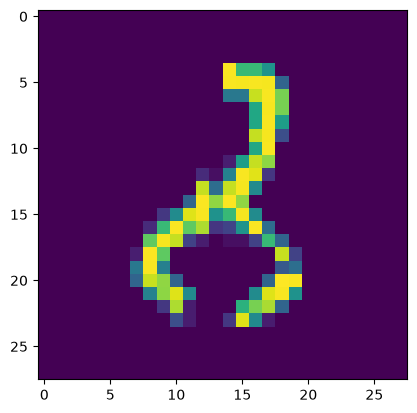

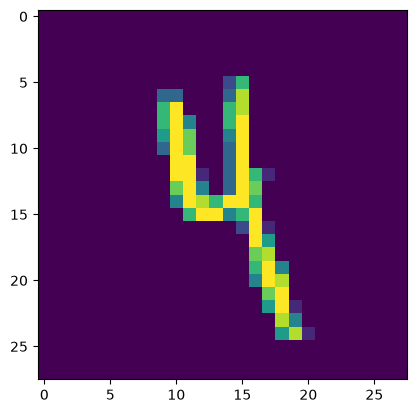

...

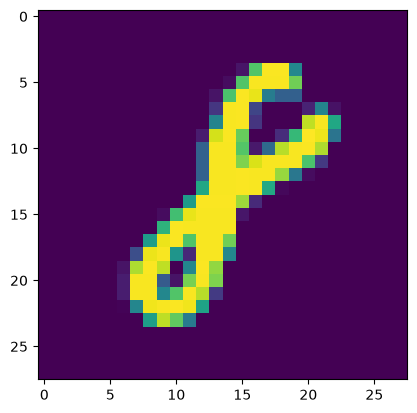

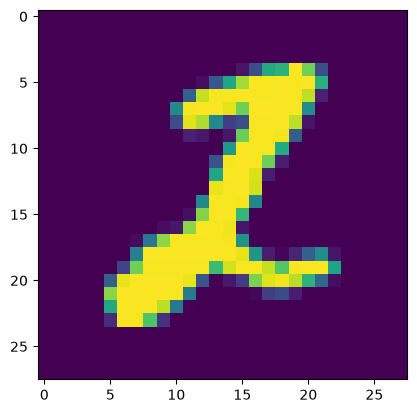

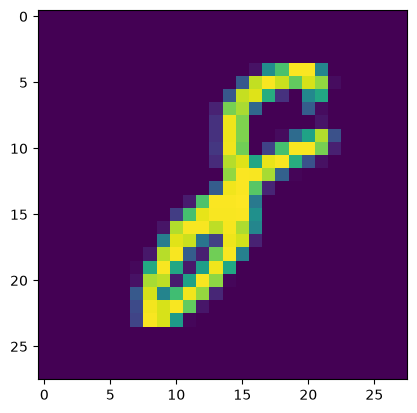

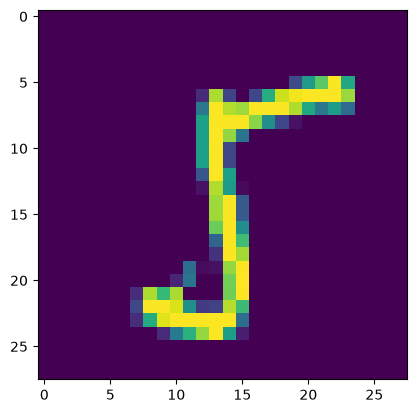

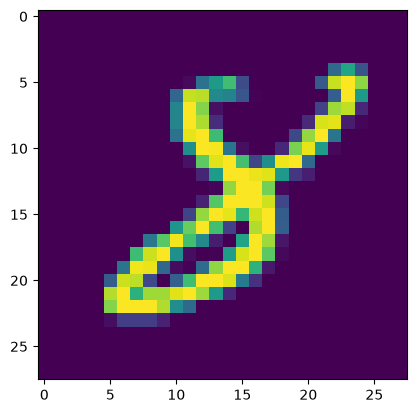

In [21]:
print("These False numbers are predicted as 1")
for i in ft:
    plt.imshow(X_test[i].reshape(28,28))
    plt.show()

**Identifying the number True 1's which were classified as False 1's**

These numbers are predicted as not 1


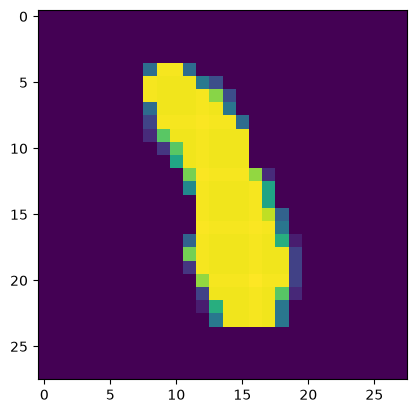

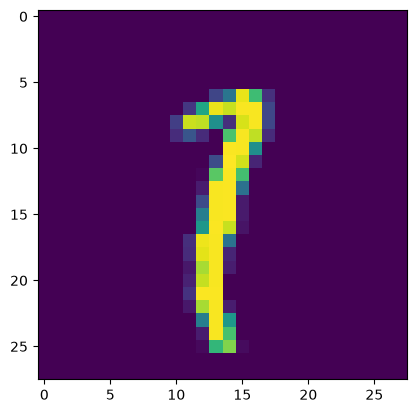

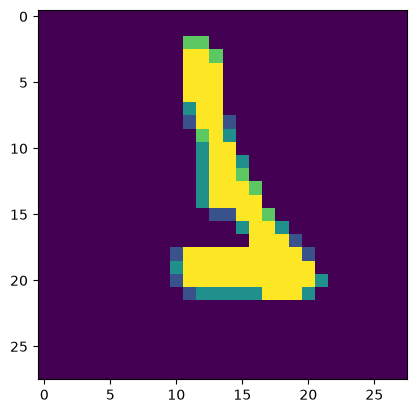

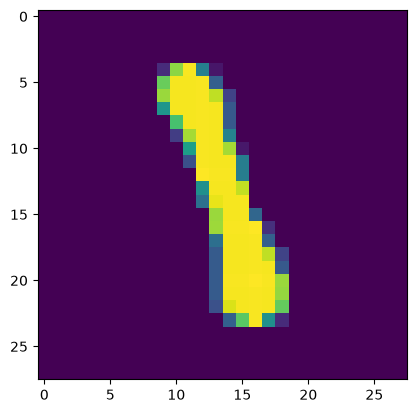

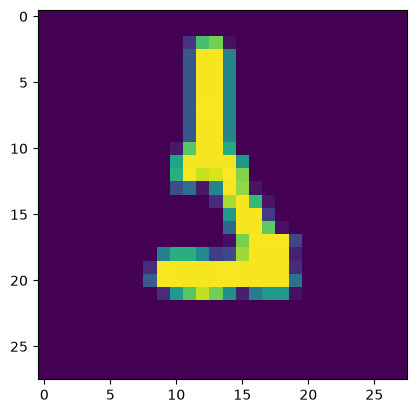

...

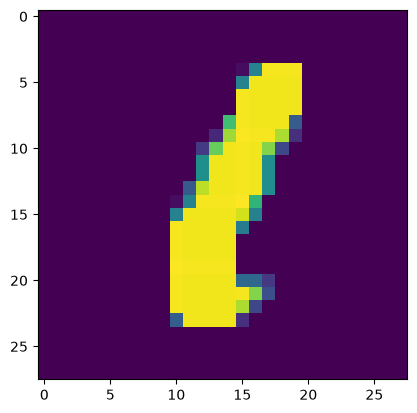

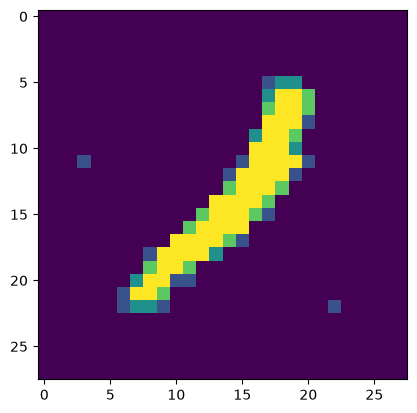

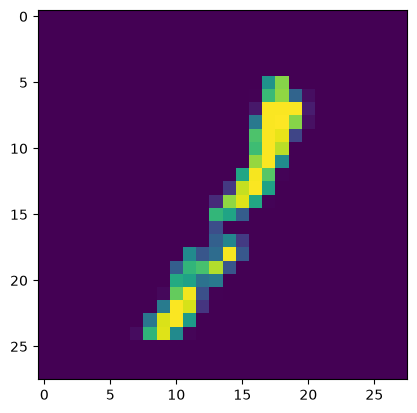

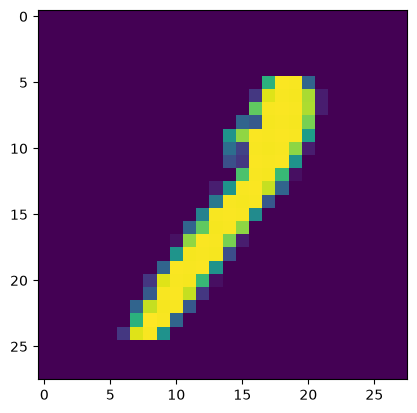

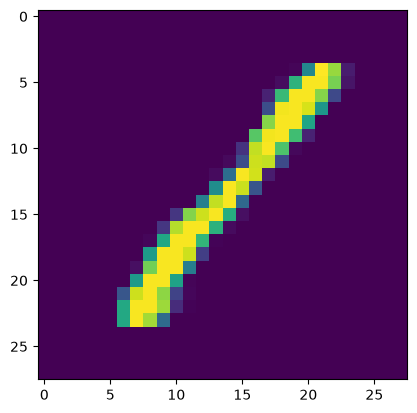

In [22]:
print("These numbers are predicted as not 1")
for i in tf:
    plt.imshow(X_test[i].reshape(28,28))
    plt.show()

**Identifying the number True 1's which were classified as True 1's**

These numbers are correctly predicted as 1 


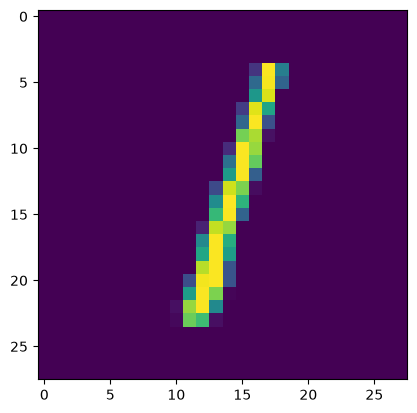

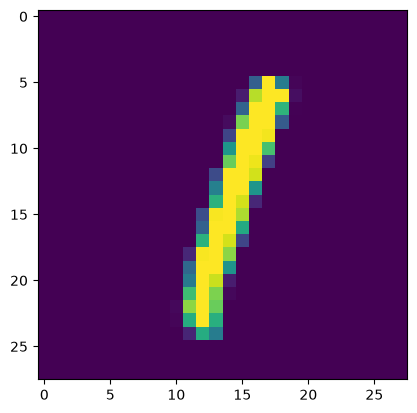

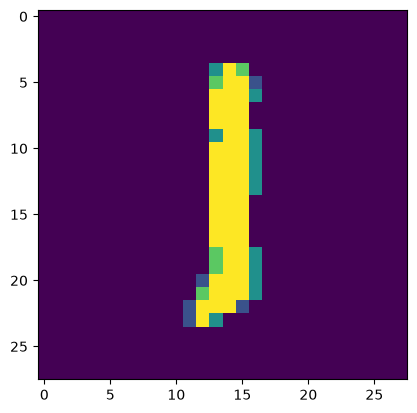

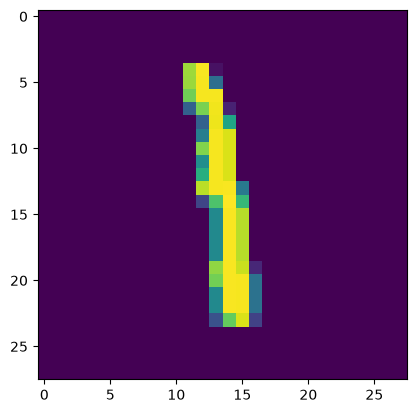

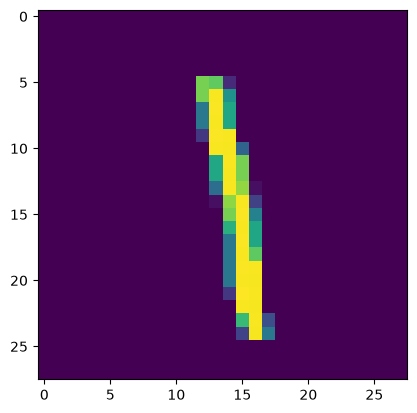

...

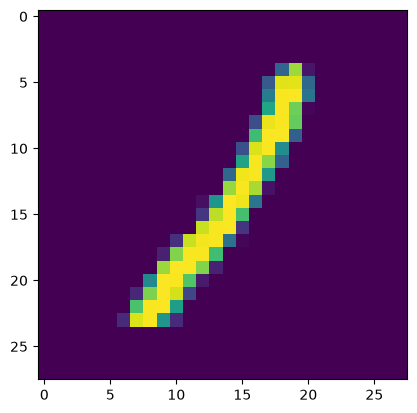

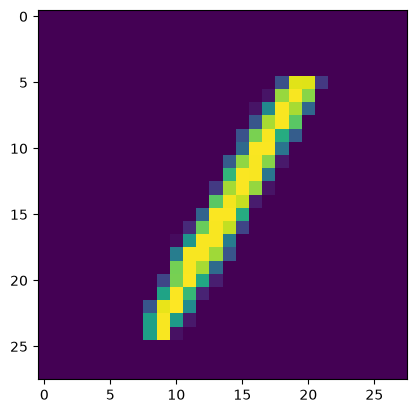

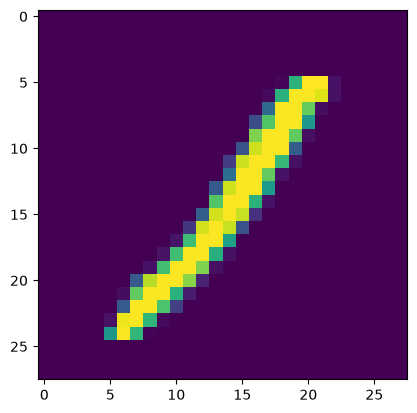

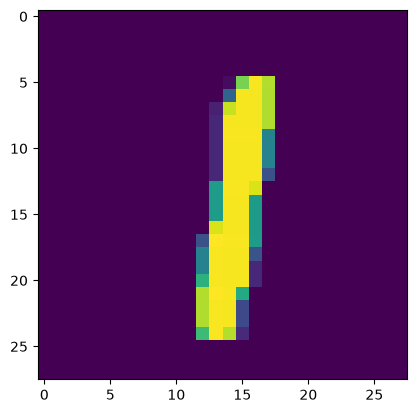

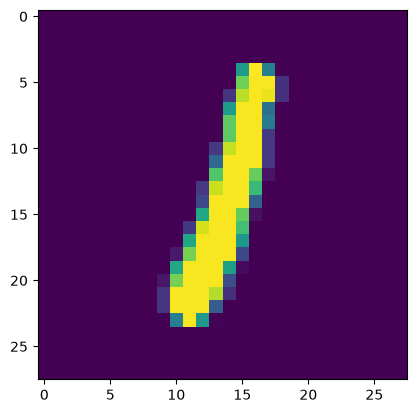

In [23]:
print("These numbers are correctly predicted as 1 ")
for i in tt:
    plt.imshow(X_test[i].reshape(28,28))
    plt.show()

**Cross Validation**

The main purpose of cross-validation is:
To get a more reliable estimate of how well our model will perform on unseen data.
Instead of relying on one train/test split, we test the model on different portions of the data.

Example: In the below code we have split the data to 3 different folds. Each fold becomes  the test data on each iteration.

In [37]:
from sklearn.model_selection import cross_val_score
cross_val_score(model, X_train, y_train_1, cv=3, scoring="accuracy")

array([0.98855, 0.98985, 0.9891 ])

In [39]:
from sklearn.base import BaseEstimator
class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        pass
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [41]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_1, cv=3, scoring="accuracy")

array([0.88625, 0.88795, 0.8887 ])

In [45]:
from sklearn.model_selection import cross_val_predict
y_scores = cross_val_predict(model, X_train, y_train_1, cv=3,
method="decision_function")

In [46]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_1, y_scores)

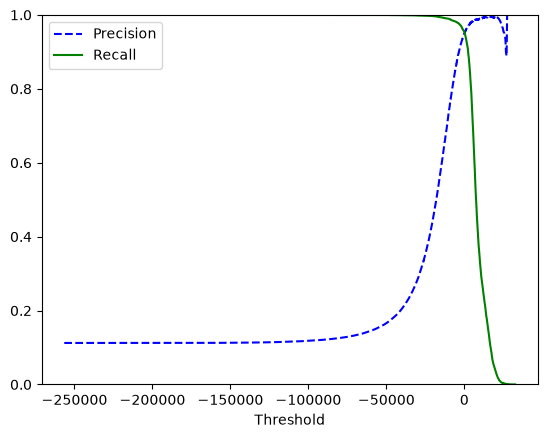

In [47]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

ROC Curve

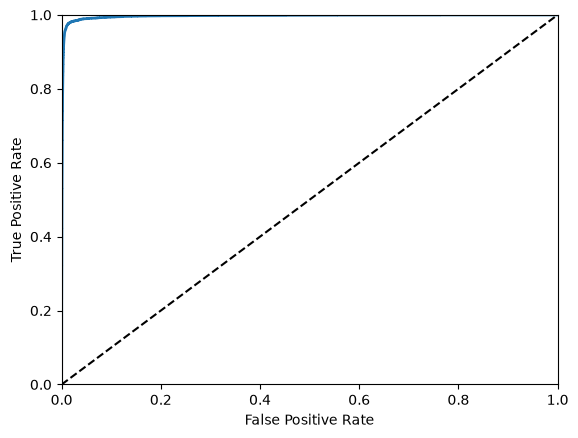

In [49]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_1, y_scores)
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
plot_roc_curve(fpr, tpr)
plt.show()


In [51]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_1, y_scores)

0.9965380182123682